In [1]:
# 1) 필요한 라이브러리 임포트
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib   # 한글 폰트 자동 적용 (NanumGothic)

from google.cloud import bigquery
from google.oauth2 import service_account

print("라이브러리 불러오기 완료!")

라이브러리 불러오기 완료!


In [2]:
# 2) BigQuery 연결 (서비스 계정 키 파일 사용)
PROJECT_ID = "project-76217e0a-c92d-4e88-a6f"
DATASET_ID = "air_quality"
TABLE_NAME = "realtime_measurements"
KEY_PATH   = "service_account_key.json"

credentials = service_account.Credentials.from_service_account_file(KEY_PATH)
bq_client   = bigquery.Client(credentials=credentials, project=PROJECT_ID)

# 테이블 경로
table_id = f"{PROJECT_ID}.{DATASET_ID}.{TABLE_NAME}"

# 실제 테이블에 접근해서 연결 여부 확인
# (키가 잘못됐거나 테이블이 없으면 여기서 바로 에러가 남)
table = bq_client.get_table(table_id)

print("BigQuery 연결 성공!")
print(f"테이블: {table_id}")
print(f"총 행 수: {table.num_rows:,}")
print(f"컬럼 수: {len(table.schema)}")

BigQuery 연결 성공!
테이블: project-76217e0a-c92d-4e88-a6f.air_quality.realtime_measurements
총 행 수: 52,416
컬럼 수: 23


In [3]:
# 3) 분석 1) 시도별 PM2.5 평균 (최근 24시간)
# SAFE_CAST: 변환 실패해도 NULL 로 넘김 (에러 X)
# TIMESTAMP_SUB(..., INTERVAL 24 HOUR): 지금부터 24시간 전 타임스탬프
sql = f"""
SELECT
  sidoName,
  ROUND(AVG(SAFE_CAST(pm25Value AS FLOAT64)), 2) AS avg_pm25,
  COUNT(*) AS n
FROM `{table_id}`
WHERE pm25Value IS NOT NULL
  AND TIMESTAMP(collected_at) >= TIMESTAMP_SUB(CURRENT_TIMESTAMP(), INTERVAL 24 HOUR)
GROUP BY sidoName
ORDER BY avg_pm25 DESC
"""

# 쿼리 실행 → 결과를 pandas DataFrame 으로 받기
df_sido = bq_client.query(sql).to_dataframe()
print(f"시도 수: {len(df_sido)}")
df_sido

시도 수: 17


C:\Users\82107\anaconda3\envs\sprint18\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,sidoName,avg_pm25,n
0,광주,25.50,208
1,전북,25.28,766
2,충북,22.48,544
3,충남,22.32,845
4,인천,21.66,657
5,서울,21.20,639
6,경기,21.05,1976
7,제주,20.96,224
8,전남,19.91,765
9,경북,19.23,841


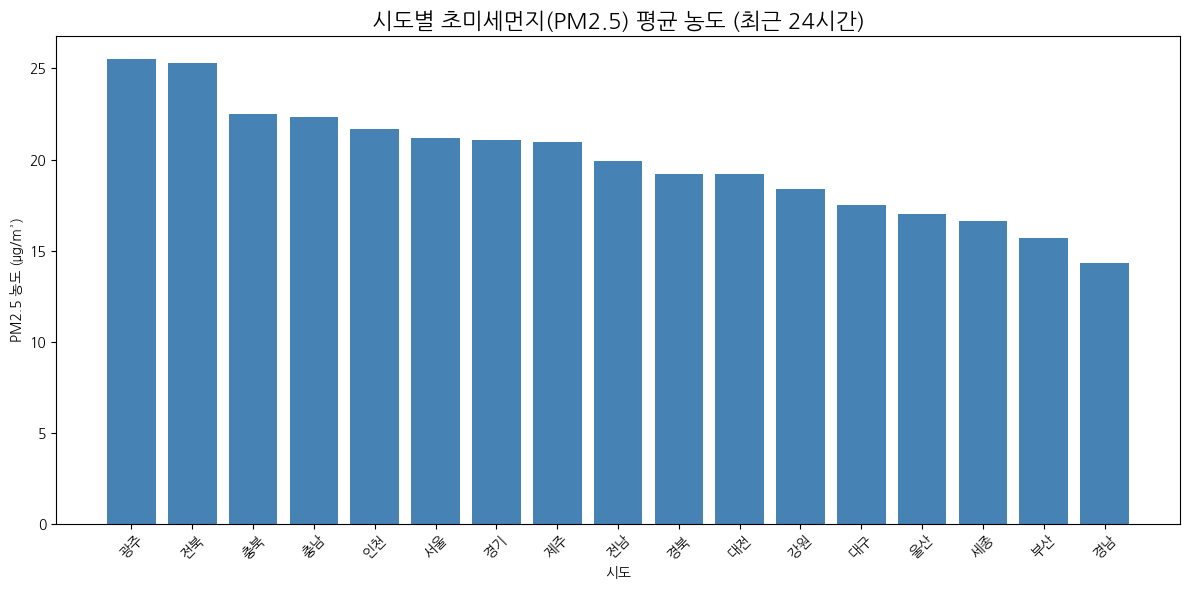

저장 완료: pm25_bar_chart.png


In [4]:
# 4) 시도별 PM2.5 막대그래프 저장
fig, ax = plt.subplots(figsize=(12, 6))                              # 그래프 영역 (가로 12 세로 6 인치)
ax.bar(df_sido["sidoName"], df_sido["avg_pm25"], color="steelblue")  # x=시도명, y=PM2.5 평균
ax.set_title("시도별 초미세먼지(PM2.5) 평균 농도 (최근 24시간)", fontsize=16)
ax.set_xlabel("시도")
ax.set_ylabel("PM2.5 농도 (μg/m³)")
plt.xticks(rotation=45)                                              # x축 라벨 45도 회전 (겹침 방지)
plt.tight_layout()                                                   # 여백 자동 조정

plt.savefig("pm25_bar_chart.png", dpi=150)                           # PNG 저장 (해상도 150dpi)
plt.show()
print("저장 완료: pm25_bar_chart.png")

In [5]:
# 5) 분석 2) 시간대별 PM10 / PM2.5 추이 (최근 7일)
# SAFE.PARSE_TIMESTAMP: dataTime 문자열("YYYY-MM-DD HH:MM") → TIMESTAMP 변환, 실패 시 NULL
# TIMESTAMP_TRUNC(ts, HOUR): 분·초 버리고 시간 단위로 뭉치기 (시간별 평균에 필수)
sql = f"""
SELECT
  TIMESTAMP_TRUNC(SAFE.PARSE_TIMESTAMP('%Y-%m-%d %H:%M', dataTime), HOUR) AS hour,
  ROUND(AVG(SAFE_CAST(pm10Value AS FLOAT64)), 2) AS avg_pm10,
  ROUND(AVG(SAFE_CAST(pm25Value AS FLOAT64)), 2) AS avg_pm25
FROM `{table_id}`
WHERE dataTime IS NOT NULL
  AND SAFE.PARSE_TIMESTAMP('%Y-%m-%d %H:%M', dataTime) IS NOT NULL
  AND TIMESTAMP(collected_at) >= TIMESTAMP_SUB(CURRENT_TIMESTAMP(), INTERVAL 7 DAY)
GROUP BY hour
ORDER BY hour
"""

df_trend = bq_client.query(sql).to_dataframe()
print(f"시간대 수: {len(df_trend)}")
df_trend.head()

시간대 수: 79


C:\Users\82107\anaconda3\envs\sprint18\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,hour,avg_pm10,avg_pm25
0,2026-04-17 16:00:00+00:00,33.00,15.00
1,2026-04-17 23:00:00+00:00,31.14,14.99
2,2026-04-18 01:00:00+00:00,27.96,14.85
3,2026-04-18 02:00:00+00:00,27.25,15.11
4,2026-04-18 03:00:00+00:00,26.56,14.49


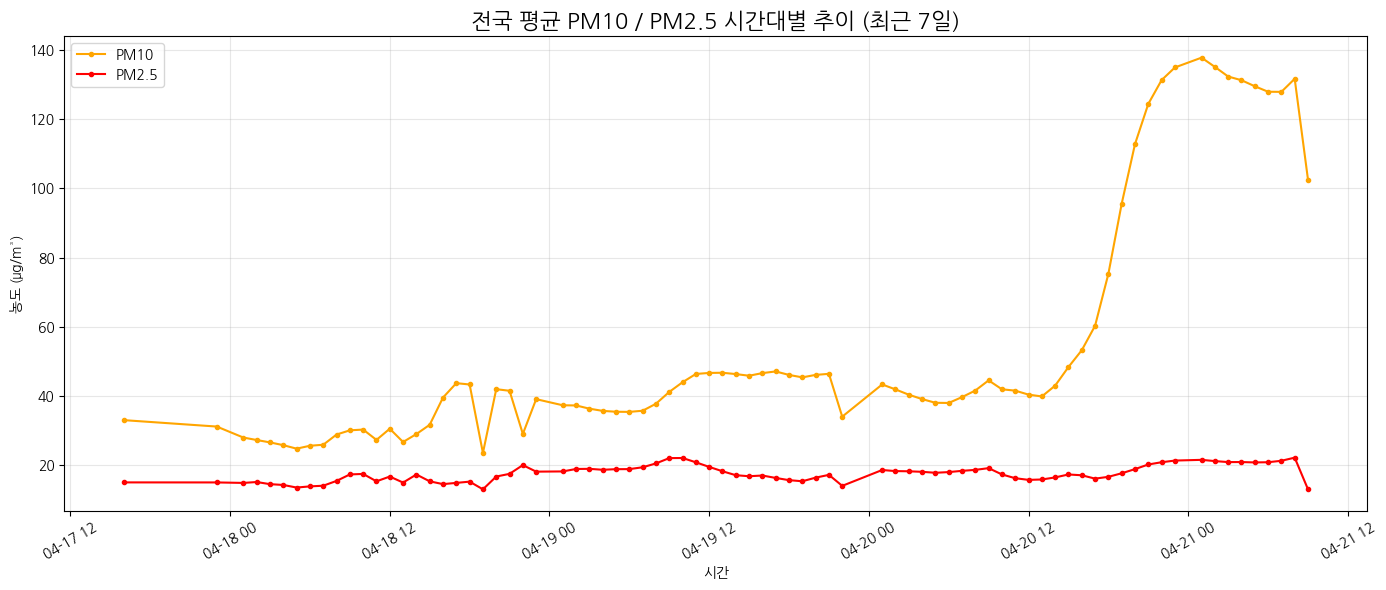

저장 완료: trend_chart.png


In [6]:
# 6) 시간대별 추이 선그래프 저장
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_trend["hour"], df_trend["avg_pm10"], label="PM10",  color="orange", marker="o", markersize=3)  # PM10 선
ax.plot(df_trend["hour"], df_trend["avg_pm25"], label="PM2.5", color="red",    marker="o", markersize=3)  # PM2.5 선
ax.set_title("전국 평균 PM10 / PM2.5 시간대별 추이 (최근 7일)", fontsize=16)
ax.set_xlabel("시간")
ax.set_ylabel("농도 (μg/m³)")
ax.legend()                                 # 범례 표시 (PM10 / PM2.5)
ax.grid(True, alpha=0.3)                    # 격자 (투명도 0.3)
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig("trend_chart.png", dpi=150)
plt.show()
print("저장 완료: trend_chart.png")

In [7]:
# 7) 분석 3) 오염물질 간 상관관계 (최근 7일)
# 6개 오염물질을 FLOAT 로 변환해서 원본 행 단위로 조회
sql = f"""
SELECT
  SAFE_CAST(so2Value  AS FLOAT64) AS so2,
  SAFE_CAST(coValue   AS FLOAT64) AS co,
  SAFE_CAST(o3Value   AS FLOAT64) AS o3,
  SAFE_CAST(no2Value  AS FLOAT64) AS no2,
  SAFE_CAST(pm10Value AS FLOAT64) AS pm10,
  SAFE_CAST(pm25Value AS FLOAT64) AS pm25
FROM `{table_id}`
WHERE TIMESTAMP(collected_at) >= TIMESTAMP_SUB(CURRENT_TIMESTAMP(), INTERVAL 7 DAY)
"""

df_corr     = bq_client.query(sql).to_dataframe()
corr_matrix = df_corr.corr()      # pandas .corr() 로 상관계수 행렬 계산 (-1 ~ +1)
print(f"조회 행 수: {len(df_corr)}")
corr_matrix.round(3)

C:\Users\82107\anaconda3\envs\sprint18\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


조회 행 수: 52416


,so2,co,o3,no2,pm10,pm25
so2,1.000,0.225,0.145,0.181,0.010,0.163
co,0.225,1.000,-0.140,0.393,-0.141,0.145
o3,0.145,-0.140,1.000,-0.364,0.143,0.058
no2,0.181,0.393,-0.364,1.000,-0.025,0.212
pm10,0.010,-0.141,0.143,-0.025,1.000,0.485
pm25,0.163,0.145,0.058,0.212,0.485,1.000


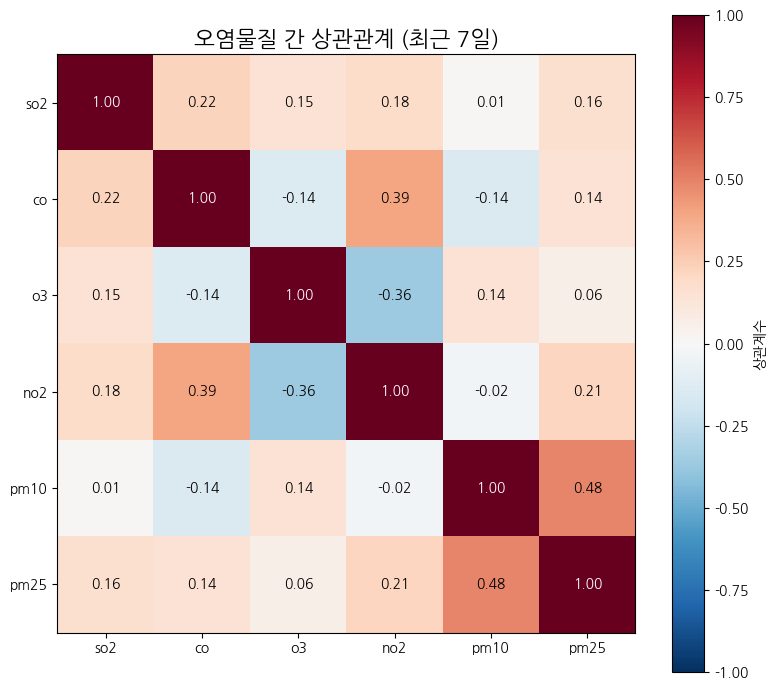

저장 완료: correlation_heatmap.png


In [8]:
# 8) 상관관계 히트맵 저장
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)   # 빨강(양) ↔ 파랑(음) 색상, -1~+1 범위 고정

# 축 레이블 (오염물질 이름)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_xticklabels(corr_matrix.columns)
ax.set_yticklabels(corr_matrix.index)

# 각 칸에 상관계수 숫자 표시
for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        value = corr_matrix.iloc[i, j]
        # 배경 색이 진한(|값|>0.5) 칸은 글자 흰색, 아니면 검정 — 가독성 확보
        if abs(value) > 0.5:
            color = "white"
        else:
            color = "black"
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", color=color)

ax.set_title("오염물질 간 상관관계 (최근 7일)", fontsize=16)
plt.colorbar(im, ax=ax, label="상관계수")      # 우측 컬러바 (값 범위 시각화)
plt.tight_layout()

plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()
print("저장 완료: correlation_heatmap.png")